In [47]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from mpl_toolkits.mplot3d import Axes3D
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score


In [48]:
df_pca  = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A1_2_PCA_training_data.csv")
df_pca = df_pca.iloc[:,1:]

df_demo = df_pca.iloc[:,:5]
df_demo = df_demo.reset_index(drop=True)

df_pca = df_pca.drop(columns=["Dataset", "Diagnosis"])
#original data 
# scaler = StandardScaler()
# data_scaled = scaler.fit_transform(df_pca)
df_pca


,Age,Sex,Site,lh_G_front_inf-Triangul_thickness,lh_G_front_middle_thickness,lh_G_front_sup_thickness,lh_G_oc-temp_lat-fusifor_thickness,lh_G_oc-temp_med-Lingual_thickness,lh_G_oc-temp_med-Parahip_thickness,lh_G_occipital_middle_thickness,...,Right-Cerebellum-White-Matter,Right-Hippocampus,Right-Inf-Lat-Vent,Right-Lateral-Ventricle,Right-Pallidum,Right-Putamen,Right-VentralDC,Right-choroid-plexus,Right-vessel,WM-hypointensities
0,52.0,0.0,11027.0,3.032,2.910,3.124,3.121,1.950,3.121,2.913,...,13226.6,4475.2,125.1,3713.2,1775.9,4594.2,3735.1,261.6,20.9,2143.1
1,62.0,0.0,11025.0,2.970,2.705,2.838,3.197,1.861,3.026,2.655,...,13410.2,3380.5,140.1,6363.8,1558.5,3867.5,3149.8,314.2,19.1,1799.1
2,60.0,0.0,11025.0,2.934,2.995,3.182,3.291,2.167,3.692,2.766,...,18425.6,4954.1,483.6,12932.1,2095.6,4804.5,4831.3,544.7,4.9,1400.7
3,54.0,0.0,11025.0,3.011,3.049,3.199,3.315,2.035,3.361,2.685,...,14006.0,4268.6,244.9,10023.3,1652.6,4262.7,3669.4,615.4,28.5,890.7
4,65.0,1.0,11027.0,2.778,2.697,2.900,2.718,1.995,2.906,2.475,...,15383.1,4198.7,821.0,17129.7,1875.9,4218.5,3865.6,1066.2,58.5,1733.5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4673,59.0,0.0,11027.0,3.362,3.085,3.318,3.269,2.099,3.520,2.677,...,15117.0,3671.1,241.1,6140.5,2054.6,4460.6,3757.5,568.4,49.7,1826.3
4674,59.0,1.0,11027.0,2.768,2.670,2.920,3.116,1.886,2.952,2.530,...,15243.3,3828.4,480.9,18586.3,2066.9,5476.6,4230.8,920.3,12.3,1430.4
4675,56.0,0.0,11025.0,3.168,2.805,3.047,3.117,2.179,3.243,2.642,...,12206.2,3677.9,271.4,6810.7,1565.7,4131.6,2944.3,372.4,43.8,819.2
4676,46.0,1.0,11025.0,3.120,2.839,3.302,3.331,2.192,3.269,2.795,...,15843.8,4524.9,152.0,6962.5,2046.1,5376.9,4255.2,478.9,38.2,1273.3


PC1:    Cummulative variance:  32.81%,  Individual variance:  32.81%
PC2:    Cummulative variance:  43.44%,  Individual variance:  10.63%
PC3:    Cummulative variance:  49.34%,  Individual variance:  5.90%
PC4:    Cummulative variance:  52.24%,  Individual variance:  2.90%
PC5:    Cummulative variance:  55.04%,  Individual variance:  2.80%
PC6:    Cummulative variance:  57.18%,  Individual variance:  2.14%
PC7:    Cummulative variance:  59.08%,  Individual variance:  1.90%
PC8:    Cummulative variance:  60.67%,  Individual variance:  1.59%
PC9:    Cummulative variance:  62.24%,  Individual variance:  1.56%
PC10:   Cummulative variance:  63.63%,  Individual variance:  1.40%


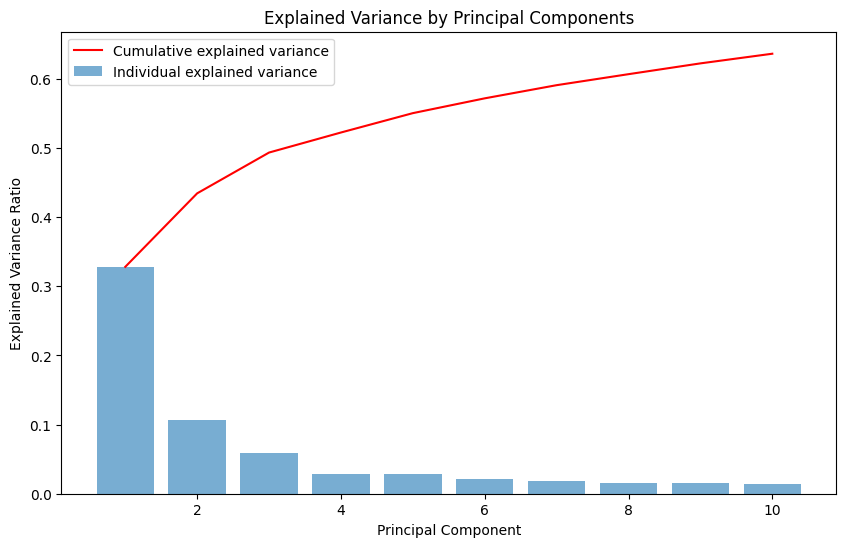

In [49]:
x = df_pca

scaler = StandardScaler()
x_scaled = scaler.fit_transform(x)

pca = PCA(n_components=10)
x_pca = pca.fit_transform(x_scaled)

cummulative_variance = 0
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    cummulative_variance += var
    if i < 10: 
        print(f'PC{i}:    Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
    else:
        print(f'PC{i}:   Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')

#plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, alpha=0.6, label='Individual explained variance')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), 'r-', label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components')
plt.legend()
plt.show()



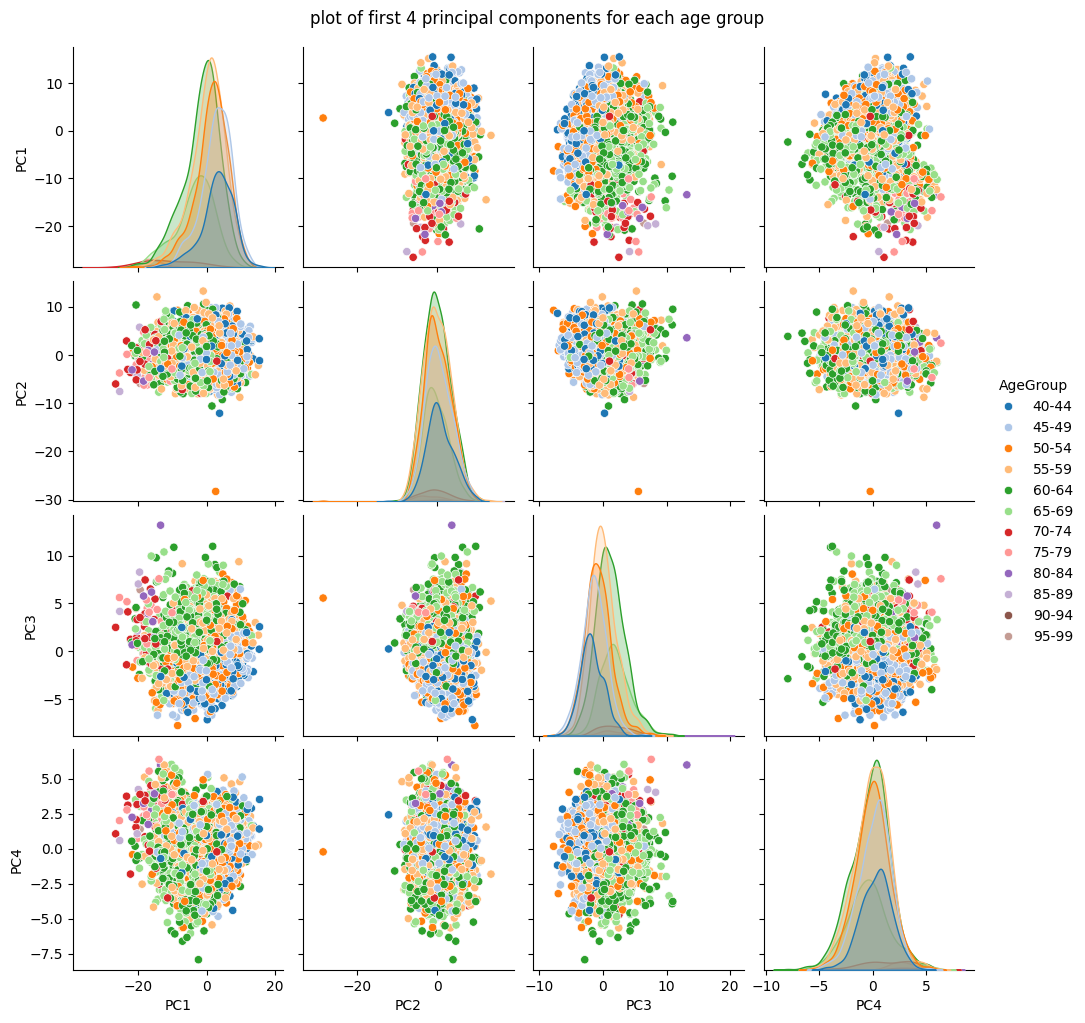

In [50]:
pca_df = pd.DataFrame(x_pca[:, :4], columns=['PC1', 'PC2', 'PC3', 'PC4'])
pca_df = pd.concat([pca_df, df_demo], axis=1)

min_age = pca_df["Age"].min()
max_age = pca_df["Age"].max()

bins = np.arange(np.floor(min_age / 5) * 5, np.ceil(max_age / 5) * 5 + 1, 5)

pca_df['AgeGroup'] = pd.cut(
    pca_df['Age'],
    bins=bins,
    labels = [f"{int(bins[i])}-{int(bins[i+1]-1)}" for i in range(len(bins)-1)],
    right=False
)

# plot
sns.pairplot(pca_df, hue="AgeGroup", vars=['PC1', 'PC2', 'PC3', 'PC4'], palette="tab20")
plt.suptitle('plot of first 4 principal components for each age group', y=1.02)
plt.show()


In [51]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

x_recon = pca.inverse_transform(x_pca)
mse = mean_squared_error(x_scaled, x_recon)
mae = mean_absolute_error(x_scaled, x_recon)
r2 = r2_score(x_scaled, x_recon)
print(f"MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}")

MSE: 0.3637
MAE: 0.4593
R²: 0.6363


MSE: 0.4557
MAE: 0.4929
R²: 0.7161

PC1:    Cummulative variance:  32.81%,  Individual variance:  32.81%
PC2:    Cummulative variance:  43.44%,  Individual variance:  10.63%
PC3:    Cummulative variance:  49.34%,  Individual variance:  5.90%
PC4:    Cummulative variance:  52.24%,  Individual variance:  2.90%
PC5:    Cummulative variance:  55.04%,  Individual variance:  2.80%
PC6:    Cummulative variance:  57.18%,  Individual variance:  2.14%
PC7:    Cummulative variance:  59.08%,  Individual variance:  1.90%
PC8:    Cummulative variance:  60.67%,  Individual variance:  1.59%
PC9:    Cummulative variance:  62.24%,  Individual variance:  1.56%
PC10:   Cummulative variance:  63.63%,  Individual variance:  1.40%


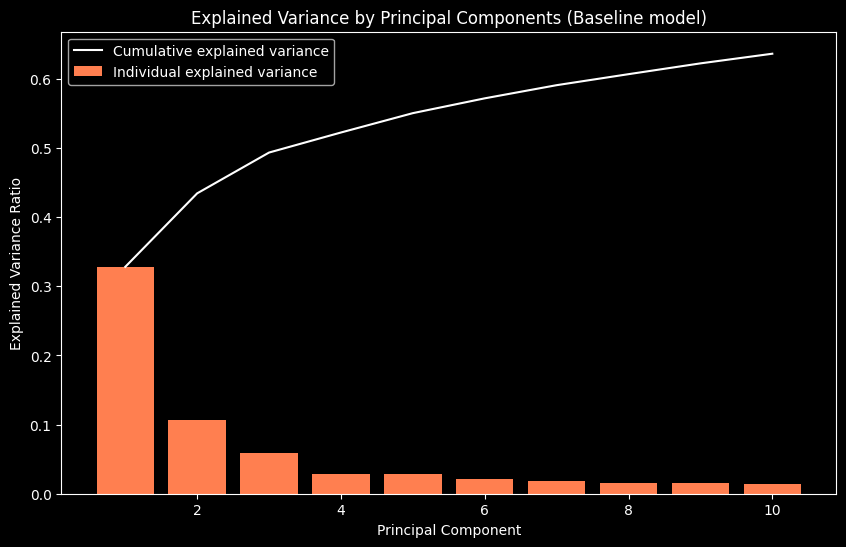

In [58]:
#now only transform the unseen data to see how well the PCA encodes for the different variables
df_pca  = pd.read_csv("/home/preclineu/quirom/Desktop/internship/Normative-Models-and-VAE/logs/Data/A2_unseen_data_ukb_adni_o3.csv")
df_pca = df_pca.iloc[:,1:]

df_pca = df_pca.drop(columns=["Dataset", "Diagnosis"])
df_pca = df_pca.dropna()

x_scaled = scaler.transform(df_pca)
pca_features = pca.transform(x_scaled)
x_recon = pca.inverse_transform(pca_features)
mse = mean_squared_error(x_scaled, x_recon)
mae = mean_absolute_error(x_scaled, x_recon)
r2 = r2_score(x_scaled, x_recon)
print(f"MSE: {mse:.4f}\nMAE: {mae:.4f}\nR²: {r2:.4f}\n")


plt.style.use("dark_background")

cummulative_variance = 0
for i, var in enumerate(pca.explained_variance_ratio_, start=1):
    cummulative_variance += var
    if i < 10: 
        print(f'PC{i}:    Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')
    else:
        print(f'PC{i}:   Cummulative variance:  {cummulative_variance:.2%},  Individual variance:  {var:.2%}')

#plot
plt.figure(figsize=(10, 6))
plt.bar(range(1, len(pca.explained_variance_ratio_) + 1), pca.explained_variance_ratio_, color='coral', label='Individual explained variance')
plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), np.cumsum(pca.explained_variance_ratio_), color='white', label='Cumulative explained variance')
plt.xlabel('Principal Component')
plt.ylabel('Explained Variance Ratio')
plt.title('Explained Variance by Principal Components (Baseline model)')
plt.legend()
plt.show()


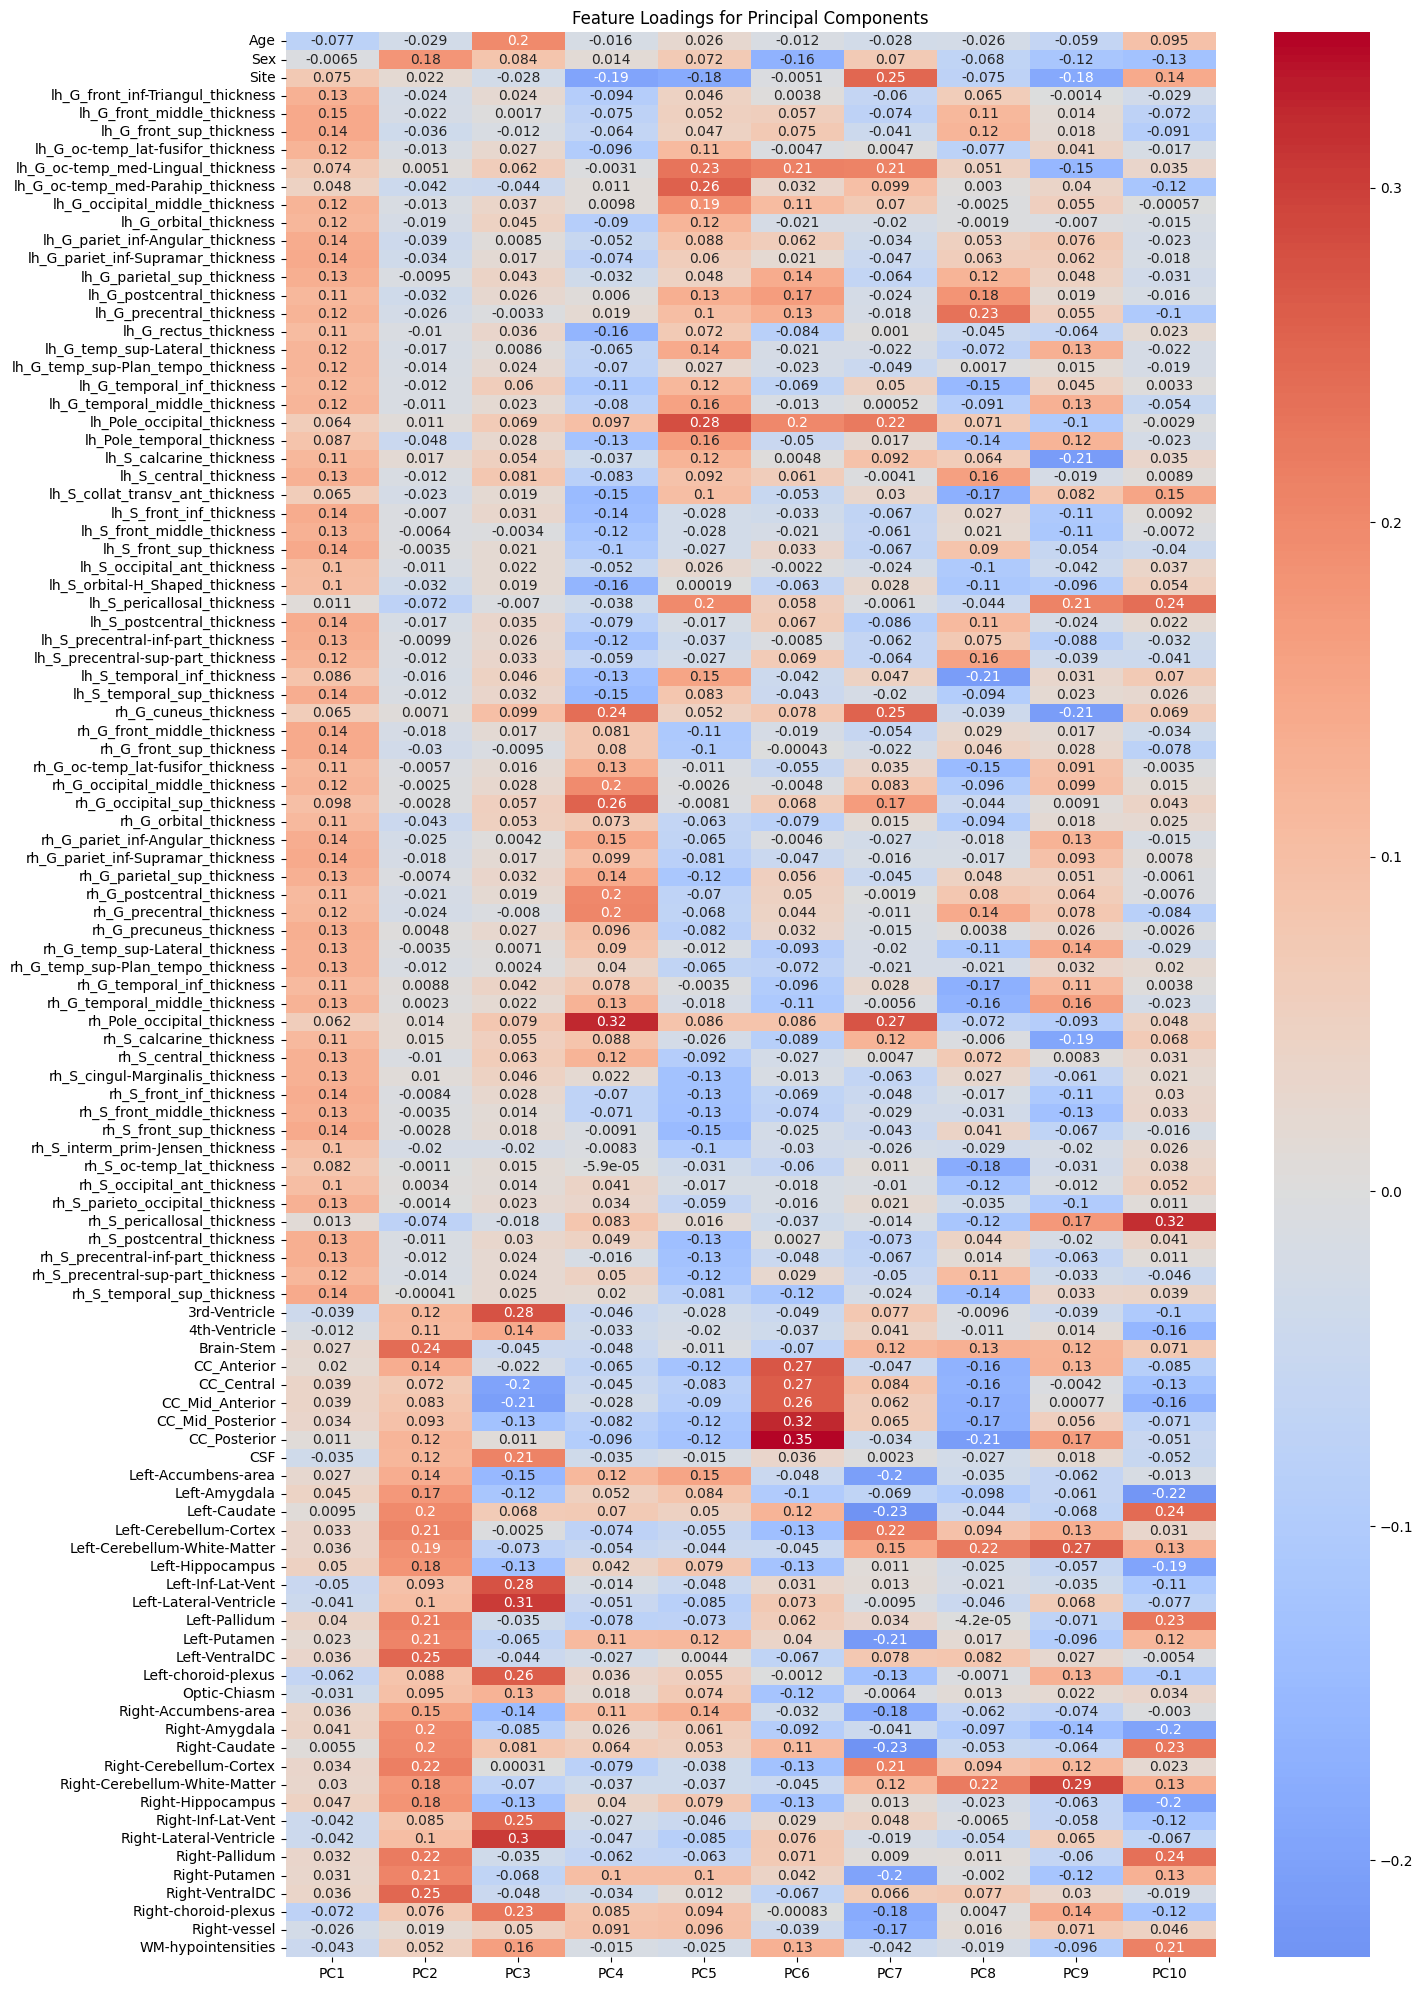

Top contributing features for PC1 :
lh_G_front_middle_thickness           0.145231
lh_S_front_sup_thickness              0.144733
lh_G_front_sup_thickness              0.144685
rh_G_front_middle_thickness           0.143183
rh_G_front_sup_thickness              0.142935
rh_S_front_sup_thickness              0.142642
lh_G_pariet_inf-Supramar_thickness    0.140765
rh_G_pariet_inf-Supramar_thickness    0.140219
rh_S_temporal_sup_thickness           0.139981
lh_S_front_inf_thickness              0.138412
lh_S_postcentral_thickness            0.138141
lh_G_pariet_inf-Angular_thickness     0.137753
rh_S_front_inf_thickness              0.136512
lh_S_temporal_sup_thickness           0.136378
rh_G_pariet_inf-Angular_thickness     0.136258
lh_S_precentral-inf-part_thickness    0.134222
rh_S_precentral-inf-part_thickness    0.134081
rh_G_precuneus_thickness              0.134030
lh_G_parietal_sup_thickness           0.133810
rh_S_postcentral_thickness            0.133132
Name: PC1, dtype: float6

KeyError: 'PC11'

In [53]:
loadings = pca.components_
feature_names = df_pca.columns

loadings_df = pd.DataFrame(loadings.T, columns=[f'PC{i+1}' for i in range(loadings.shape[0])], index=feature_names)

plt.figure(figsize=(15,25))
sns.heatmap(loadings_df.iloc[:, :10], annot=True, cmap='coolwarm', center=0)
plt.title('Feature Loadings for Principal Components')
plt.show()

for i in range(1,21):
    pc_name = f'PC{i}'
    pc_loadings = loadings_df[pc_name].sort_values(ascending=False)
    print(f"Top contributing features for {pc_name} :")
    print(pc_loadings.head(20))
    print('\n')
